# Stage 2 — linear baselines (PCA / dPCA / GPFA)

Visualize the artifacts written by `src/000447/02_baseline_linear.py`. CA1 and
PFC are kept separate throughout.

1. **PCA** — scree / cumulative variance; PC1-PC2-PC3 scores colored by condition
2. **dPCA** — variance split into space / condition / interaction, laps as trials
   (CV-chosen regularizer + permutation significance)
3. **GPFA** — per-lap latents re-expressed vs. linearized track position, novel
   vs. familiar

Run `pixi run python src/000447/02_baseline_linear.py` first if artifacts are missing.

## Setup

In [1]:
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "common" / "config.py").exists())
for _d in ("common", "000447"):
    sys.path.insert(0, str(_root / "src" / _d))
import numpy as np
import matplotlib.pyplot as plt
from config import processed_dir, BIN_SIZE_S
DATA_PROCESSED = processed_dir("000447")
BIN_MS = int(BIN_SIZE_S * 1000)
plt.rcParams["figure.dpi"] = 100
COND_COLOR = {"novel": "tab:red", "familiar": "tab:blue"}
print("bin size:", BIN_MS, "ms")

bin size: 1000 ms


## 1. PCA — variance and low-D scores
Pick one subject/region for the scores plot; scree shown for the same file.

0 pca_JDS-NFN-AM2_CA1_1000ms.npz
1 pca_JDS-NFN-AM2_PFC_1000ms.npz
2 pca_JDS-NFN-JS17_CA1_1000ms.npz
3 pca_JDS-NFN-JS17_PFC_1000ms.npz
4 pca_JDS-NFN-JS21_CA1_1000ms.npz
5 pca_JDS-NFN-JS21_PFC_1000ms.npz
6 pca_JDS-NFN-JS34_CA1_1000ms.npz
7 pca_JDS-NFN-JS34_PFC_1000ms.npz
8 pca_JDS-NFN-ZT2_CA1_1000ms.npz
9 pca_JDS-NFN-ZT2_PFC_1000ms.npz


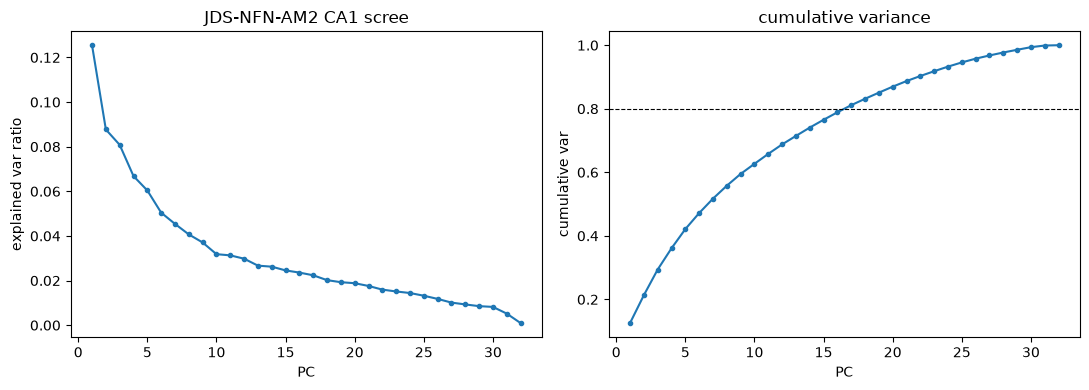

In [2]:
pca_files = sorted(DATA_PROCESSED.glob(f"pca_*_{BIN_MS}ms.npz"))
for i, f in enumerate(pca_files): print(i, f.name)
p = np.load(pca_files[0], allow_pickle=False)
subject, region = str(p["subject"]), str(p["region"])
evr = p["explained_variance_ratio"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, len(evr) + 1), evr, "o-", ms=3)
axes[0].set_xlabel("PC"); axes[0].set_ylabel("explained var ratio")
axes[0].set_title(f"{subject} {region} scree")
axes[1].plot(np.arange(1, len(evr) + 1), np.cumsum(evr), "o-", ms=3)
axes[1].axhline(0.8, color="k", ls="--", lw=0.8)
axes[1].set_xlabel("PC"); axes[1].set_ylabel("cumulative var")
axes[1].set_title("cumulative variance")
plt.tight_layout()

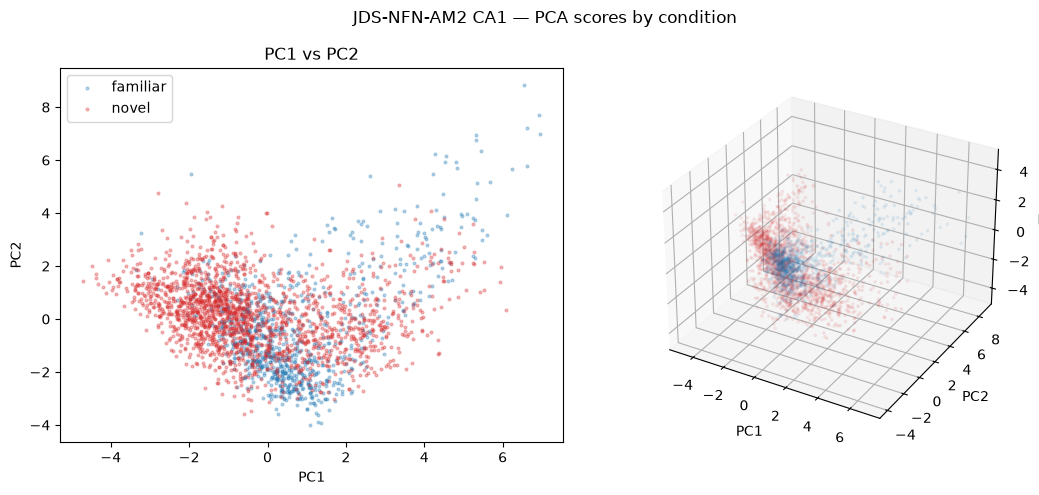

In [3]:
scores, condition = p["scores"], p["condition"]
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for c in np.unique(condition):
    m = condition == c
    axes[0].scatter(scores[m, 0], scores[m, 1], s=4, alpha=0.3,
                    color=COND_COLOR.get(c), label=c)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend(); axes[0].set_title("PC1 vs PC2")
ax = fig.add_subplot(1, 2, 2, projection="3d")
for c in np.unique(condition):
    m = condition == c
    ax.scatter(scores[m, 0], scores[m, 1], scores[m, 2], s=3, alpha=0.3,
               color=COND_COLOR.get(c), label=c)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
axes[1].remove()
fig.suptitle(f"{subject} {region} — PCA scores by condition")
plt.tight_layout()

## 2. dPCA — variance demixing across all subjects

Fraction of variance captured by components that depend on **space**, on
**condition** (novel/familiar), and on their **interaction** (a space-dependent
remap vs. a global condition shift).

Each **lap** (a trials-table row) is a trial, so these are cross-validated
numbers, not point estimates on an over-fit mean: the regularizer is chosen by
lap-level K-fold CV, and the condition / interaction variance fractions are
tested by permuting the condition label across laps (`*` = permutation p < 0.05).

,subject,region,space,condition,interaction,p_c,p_cs,reg,n_laps
0,AM2,CA1,0.361,0.149,0.289,0.005,0.005,0.001,104
1,AM2,PFC,0.320,0.138,0.306,0.005,0.005,0.001,104
2,JS17,CA1,0.526,0.138,0.128,0.005,0.005,0.001,155
3,JS17,PFC,0.572,0.093,0.135,0.005,0.005,0.001,155
4,JS21,CA1,0.252,0.304,0.224,0.005,0.005,0.000,116
5,JS21,PFC,0.342,0.225,0.236,0.005,0.005,0.001,116
6,JS34,CA1,0.296,0.096,0.345,0.005,0.005,0.001,239
7,JS34,PFC,0.320,0.162,0.292,0.005,0.005,0.001,239
8,ZT2,CA1,0.255,0.301,0.219,0.005,0.025,0.001,126
9,ZT2,PFC,0.406,0.052,0.305,0.005,0.005,0.001,126


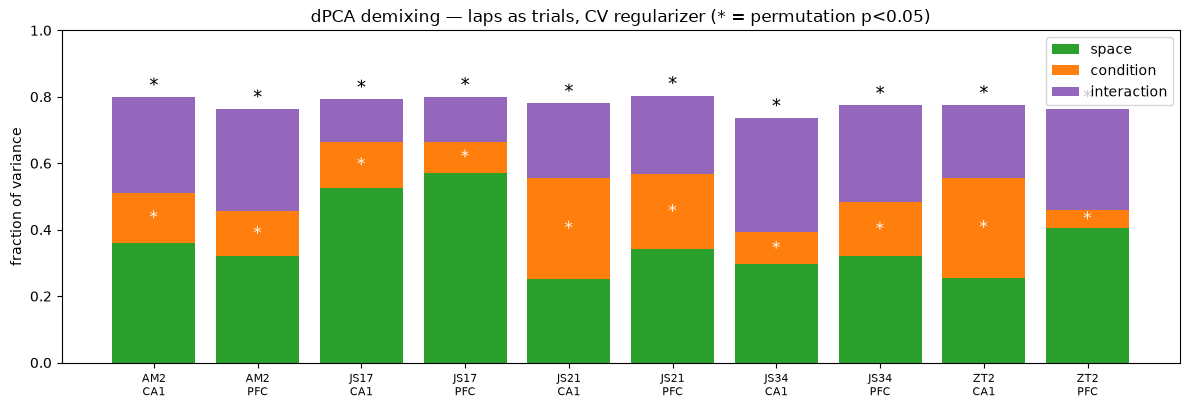

In [4]:
import pandas as pd
dpca_files = sorted(DATA_PROCESSED.glob(f"dpca_*_{BIN_MS}ms.npz"))
rows = []
for f in dpca_files:
    d = np.load(f, allow_pickle=False)
    rows.append((str(d["subject"]).split("-")[-1], str(d["region"]),
                 float(d["evr_s"].sum()), float(d["evr_c"].sum()), float(d["evr_cs"].sum()),
                 float(d["p_c"]), float(d["p_cs"]), float(d["regularizer"]), int(d["n_laps"])))
df = pd.DataFrame(rows, columns=["subject", "region", "space", "condition",
                                 "interaction", "p_c", "p_cs", "reg", "n_laps"])
x = np.arange(len(df))
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.bar(x, df.space, label="space", color="tab:green")
ax.bar(x, df.condition, bottom=df.space, label="condition", color="tab:orange")
ax.bar(x, df.interaction, bottom=df.space + df.condition, label="interaction", color="tab:purple")
for i, r in df.iterrows():                      # permutation-significance stars
    if r.p_c < 0.05:
        ax.text(i, r.space + r.condition / 2, "*", ha="center", va="center", color="white", fontsize=12)
    if r.p_cs < 0.05:
        ax.text(i, r.space + r.condition + r.interaction + 0.02, "*", ha="center", fontsize=13)
ax.set_xticks(x); ax.set_xticklabels([f"{s}\n{r}" for s, r in zip(df.subject, df.region)], fontsize=8)
ax.set_ylabel("fraction of variance"); ax.set_ylim(0, 1); ax.legend()
ax.set_title("dPCA demixing — laps as trials, CV regularizer (* = permutation p<0.05)")
plt.tight_layout()
df.round(3)

## 3. GPFA — latents vs. track position

Each **lap** is one GPFA trial; the latent trajectory is then re-expressed as a
function of **linearized track position**. Averaging across laps within a
condition at matched positions makes the latents directly comparable between
novel and familiar (novel/familiar use each condition's own W-track graph, so
linear position means the same thing across them).

0 gpfa_JDS-NFN-AM2_CA1.npz
1 gpfa_JDS-NFN-AM2_PFC.npz
2 gpfa_JDS-NFN-JS17_CA1.npz
3 gpfa_JDS-NFN-JS17_PFC.npz
4 gpfa_JDS-NFN-JS21_CA1.npz
5 gpfa_JDS-NFN-JS21_PFC.npz
6 gpfa_JDS-NFN-JS34_CA1.npz
7 gpfa_JDS-NFN-JS34_PFC.npz
8 gpfa_JDS-NFN-ZT2_CA1.npz
9 gpfa_JDS-NFN-ZT2_PFC.npz


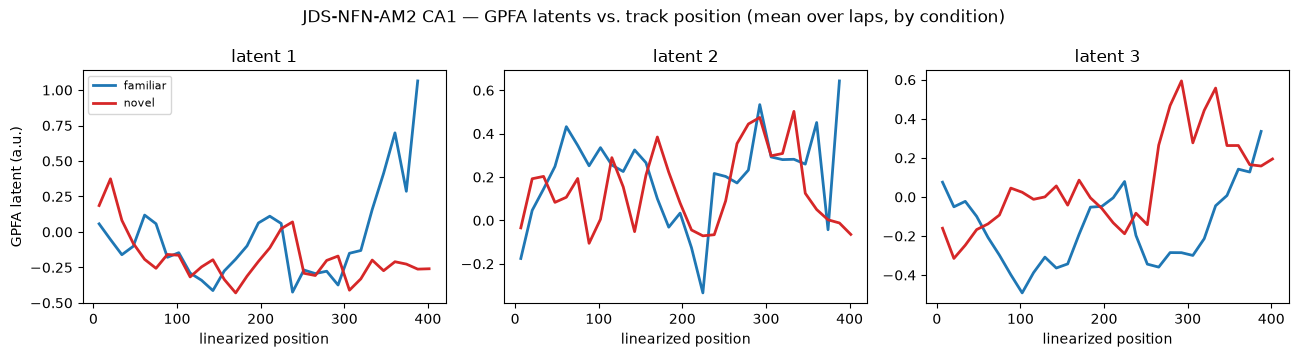

In [5]:
import warnings
gpfa_files = sorted(DATA_PROCESSED.glob("gpfa_*.npz"))
if not gpfa_files:
    print("no GPFA artifacts yet — run: pixi run python src/000447/02_baseline_linear.py --method gpfa")
else:
    for i, f in enumerate(gpfa_files): print(i, f.name)
    g = np.load(gpfa_files[0], allow_pickle=False)
    lat = g["latents_posidx"]            # (n_laps, x_dim, n_posbins), NaN where unvisited
    pos = g["posbin_centers"]
    cond = g["lap_condition"]
    subject, region = str(g["subject"]), str(g["region"])
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)
    for dim, ax in enumerate(axes):
        for c in np.unique(cond):
            with warnings.catch_warnings():     # NaN posbins a condition never visits
                warnings.simplefilter("ignore")
                mean_traj = np.nanmean(lat[cond == c][:, dim, :], axis=0)
            ax.plot(pos, mean_traj, color=COND_COLOR.get(c), label=c, lw=2)
        ax.set_title(f"latent {dim + 1}"); ax.set_xlabel("linearized position")
    axes[0].set_ylabel("GPFA latent (a.u.)"); axes[0].legend(fontsize=8)
    fig.suptitle(f"{subject} {region} — GPFA latents vs. track position (mean over laps, by condition)")
    plt.tight_layout()

---
**Next:** stage 3 (`src/03_nonlinear_embedding.py`) — CEBRA (behavior-aligned),
UMAP, Isomap — to compare against these linear baselines.